In [1]:
# ============================
# 1. IMPORTS E CONFIGURAÇÃO
# ============================
import requests
import pandas as pd
import numpy as np
import io
import re
import string
from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

# Se for a primeira execução, descomente estas linhas:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# ============================
# 2. PARÂMETROS GERAIS
# ============================

# Quantos dias para trás considerar (fácil de alterar)
DAYS_BACK = 90  # altere para 90, 180, 365, etc., se quiser mais histórico

BASE_URL = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"

# Datas (hoje e limite mínimo)
today = datetime.utcnow().date()
date_received_max = today.strftime("%Y-%m-%d")
date_received_min = (today - timedelta(days=DAYS_BACK)).strftime("%Y-%m-%d")

print("Coletando dados de", date_received_min, "até", date_received_max)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Coletando dados de 2025-12-24 até 2026-03-24


/tmp/ipykernel_3453/4076638015.py:44: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  today = datetime.utcnow().date()


In [2]:
import requests
import pandas as pd
import io

BASE_URL = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"

def fetch_complaints(date_min: str, date_max: str, max_size: int = 50000) -> pd.DataFrame:
    """
    Busca reclamações na API pública do CFPB no intervalo [date_min, date_max].
    - date_min, date_max: strings no formato 'YYYY-MM-DD'
    - max_size: número máximo total de registros desejados (vamos paginar em lotes de até 10000)
    Retorna um DataFrame com os dados.
    """

    # A API documenta retorno em json/csv/xls/xlsx e suporta paginação via 'page' e 'size',
    # com limite típico de 10000 por página.[web:57]
    PAGE_SIZE = 10000
    size = min(PAGE_SIZE, max_size)

    headers = {
        # Coloque algo identificável seu aqui (pode incluir email institucional)
        "User-Agent": "POS-TECH-Datathon/1.0 (Google Colab; contato: seu_email@exemplo.com)"
    }

    all_dfs = []
    total_fetched = 0
    page = 1

    while total_fetched < max_size:
        params = {
            "date_received_min": date_min,
            "date_received_max": date_max,
            "has_narrative": "true",
            "no_aggs": "true",
            "field": "all",
            "format": "csv",   # a API suporta csv/json/xls/xlsx[web:57]
            "size": size,
            "page": page
        }

        print(f"Buscando página {page} (size={size})...")
        resp = requests.get(BASE_URL, params=params, headers=headers, timeout=30)

        # Debug rápido se ainda der problema
        print("Status code:", resp.status_code)
        if resp.status_code == 403:
            print("Resposta 403 - Forbidden. Tente rodar de outro ambiente (sem VPN) "
                  "ou reduzir ainda mais o size, por exemplo size=1000.")
            resp.raise_for_status()

        resp.raise_for_status()

        csv_data = io.StringIO(resp.text)
        df_page = pd.read_csv(csv_data)

        if df_page.empty:
            print("Página vazia, encerrando paginação.")
            break

        all_dfs.append(df_page)
        fetched = len(df_page)
        total_fetched += fetched
        print(f"Página {page}: {fetched} registros. Total acumulado: {total_fetched}.")

        if fetched < size:
            # Última página (não há mais dados)
            break

        page += 1

    if not all_dfs:
        return pd.DataFrame()

    df = pd.concat(all_dfs, ignore_index=True)
    return df

# Uso:
df_raw = fetch_complaints(date_received_min, date_received_max, max_size=50000)
print("Registros brutos retornados:", df_raw.shape)
df_raw.head()


Buscando página 1 (size=10000)...
Status code: 200
Página 1: 32895 registros. Total acumulado: 32895.
Buscando página 2 (size=10000)...
Status code: 200
Página 2: 32895 registros. Total acumulado: 65790.
Registros brutos retornados: (65790, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,02/19/26,Credit card,General-purpose credit card or charge card,Fees or interest,Problem with fees,I had a CITI bank Best Buy card account ending...,Company has responded to the consumer and the ...,"CITIBANK, N.A.",FL,32246,NaN,Consent provided,Web,02/19/26,Closed with monetary relief,Yes,NaN,19620152
1,02/24/26,Debt collection,Mortgage debt,Written notification about debt,Didn't receive enough information to verify debt,Subject : Incorrect late payment reported for ...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",TX,XXXXX,Servicemember,Consent provided,Web,02/24/26,Closed with non-monetary relief,Yes,NaN,19743943
2,01/22/26,Credit card,General-purpose credit card or charge card,Problem with a purchase shown on your statement,Credit card company isn't resolving a dispute ...,"On XX/XX/year>, I used my Citi bank credit car...",Company has responded to the consumer and the ...,"CITIBANK, N.A.",OH,45215,NaN,Consent provided,Web,01/22/26,Closed with explanation,Yes,NaN,18917331
3,01/13/26,Debt collection,Payday loan debt,Electronic communications,Frequent or repeated messages,I am submitting this complaint to report an un...,Company believes complaint caused principally ...,BlueChip Financial,IN,46835,NaN,Consent provided,Web,01/13/26,Closed with explanation,Yes,NaN,18687860
4,01/06/26,Credit card,General-purpose credit card or charge card,Getting a credit card,Sent card you never applied for,"XX/XX/XXXX2025 XXXX XXXX XXXX, XXXX, NH XXXX S...",NaN,"Bread Financial Holdings, Inc.",NH,03060,Older American,Consent provided,Web,01/06/26,Closed with non-monetary relief,Yes,NaN,18511445


In [5]:
# Dicionários simples de palavras
positive_words = [
    "resolved", "thank", "helpful", "satisfied", "good", "great", "appreciate"
]

negative_words = [
    "error", "fraud", "complaint", "unauthorized", "charged",
    "problem", "issue", "bad", "poor", "delay", "denied"
]

def rule_based_sentiment(row):
    text = str(row.get("Consumer complaint narrative", "")).lower()

    pos_count = sum(word in text for word in positive_words)
    neg_count = sum(word in text for word in negative_words)

    if pos_count > neg_count:
        return "positive"
    else:
        return "negative"

df = df_raw.copy()
df["sentiment"] = df.apply(rule_based_sentiment, axis=1)

# Remove linhas sem sentimento definido
df = df[df["sentiment"].notna()].reset_index(drop=True)

print("Distribuição de sentimento:")
print(df["sentiment"].value_counts())


Distribuição de sentimento:
sentiment
negative    62806
positive     2984
Name: count, dtype: int64


In [6]:
# ============================
# 5. PRÉ-PROCESSAMENTO DO TEXTO
# ============================

TEXT_COL = "Consumer complaint narrative"

# Remove linhas sem texto
df = df[df[TEXT_COL].notna()].reset_index(drop=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """
    Limpa e normaliza o texto:
    - lowercase
    - remove URLs, números, pontuação
    - remove stopwords
    - aplica lematização
    """
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\\S+|www\\.\\S+", " ", text)

    # Mantém apenas letras e espaço
    text = re.sub(r"[^a-z\\s]", " ", text)

    # Tokenização simples por espaço
    tokens = text.split()

    # Remove stopwords e lematiza
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in stop_words and len(tok) > 2
    ]

    return " ".join(tokens)

# Cria coluna com texto limpo
df["clean_text"] = df[TEXT_COL].astype(str).apply(clean_text)

# Remove entradas com texto limpo vazio (se houver)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

print("Exemplo de texto original vs limpo:")
for i in range(3):
    print("Original:", df.loc[i, TEXT_COL][:200])
    print("Limpo  :", df.loc[i, "clean_text"][:200])
    print("-" * 80)


Exemplo de texto original vs limpo:
Original: I had a CITI bank Best Buy card account ending in XXXX that was unknowingly auto renewed and fees were applied and accrued. Immediately upon discovery of this account and fees, the account was closed 
Limpo  : citi bank best buy card account ending xxxx unknowingly auto renewed fee applied accrued immediately upon discovery account fee account closed paid best buy prorated paid remaining balance directly ci
--------------------------------------------------------------------------------
Original: Subject : Incorrect late payment reported for mortgage account # XXXX Complaint : On XX/XX/year>, I made my full mortgage payment of {$970.00} by online payment/ACH/check and the payment cleared my ba
Limpo  : subject incorrect late payment reported mortgage account xxxx complaint year made full mortgage payment online payment ach check payment cleared bank date servicer xxxx xxxx xxxx xxxx reported xxxx da
-----------------------------------------

In [7]:
# ============================
# 6. SPLIT TREINO/TESTE E TOKENIZAÇÃO
# ============================

X = df["clean_text"].values
y = df["sentiment"].map({"negative": 0, "positive": 1}).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

MAX_WORDS = 20000   # vocabulário (pode ajustar)
MAX_LEN = 200       # tamanho máximo da sequência (pode ajustar)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Converte textos em sequências de índices
seq_train = tokenizer.texts_to_sequences(X_train)
seq_test = tokenizer.texts_to_sequences(X_test)

# Pad/truncate para comprimento fixo
X_train_pad = pad_sequences(seq_train, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(seq_test, maxlen=MAX_LEN, padding="post", truncating="post")

print("Shape X_train_pad:", X_train_pad.shape)
print("Shape X_test_pad :", X_test_pad.shape)


Shape X_train_pad: (52632, 200)
Shape X_test_pad : (13158, 200)


In [8]:
# ============================
# 7. MODELO DE DEEP LEARNING
# ============================

VOCAB_SIZE = min(MAX_WORDS, len(tokenizer.word_index) + 1)
EMBED_DIM = 100      # dimensão do embedding
LSTM_UNITS = 64

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True)),
    tf.keras.layers.GlobalMaxPool1D(),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

EPOCHS = 5       # ajuste conforme sua infra
BATCH_SIZE = 128

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# Avaliação no conjunto de teste
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Acurácia em teste: {test_acc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
371/371 ━━━━━━━━━━━━━━━━━━━━ 243s 641ms/step - accuracy: 0.9534 - loss: 0.1833 - val_accuracy: 0.9649 - val_loss: 0.1006
Epoch 2/5
371/371 ━━━━━━━━━━━━━━━━━━━━ 263s 645ms/step - accuracy: 0.9764 - loss: 0.0681 - val_accuracy: 0.9894 - val_loss: 0.0306
Epoch 3/5
371/371 ━━━━━━━━━━━━━━━━━━━━ 237s 639ms/step - accuracy: 0.9913 - loss: 0.0278 - val_accuracy: 0.9873 - val_loss: 0.0443
Epoch 4/5
371/371 ━━━━━━━━━━━━━━━━━━━━ 238s 641ms/step - accuracy: 0.9941 - loss: 0.0193 - val_accuracy: 0.9916 - val_loss: 0.0298
Epoch 5/5
371/371 ━━━━━━━━━━━━━━━━━━━━ 239s 642ms/step - accuracy: 0.9967 - loss: 0.0105 - val_accuracy: 0.9937 - val_loss: 0.0261
Acurácia em teste: 0.9950


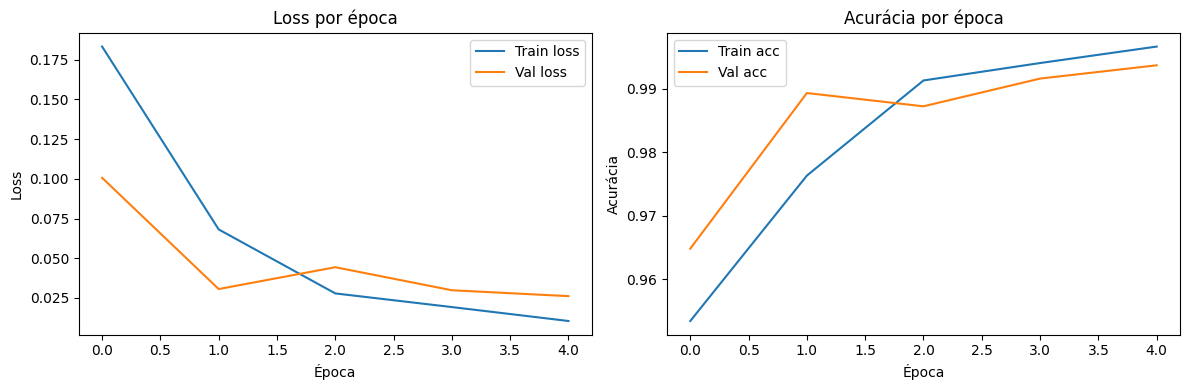

412/412 ━━━━━━━━━━━━━━━━━━━━ 23s 55ms/step


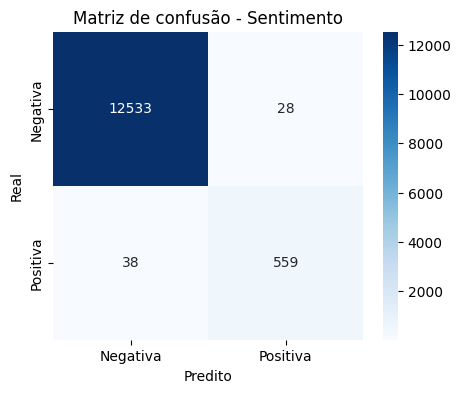

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     12561
    positive       0.95      0.94      0.94       597

    accuracy                           0.99     13158
   macro avg       0.97      0.97      0.97     13158
weighted avg       0.99      0.99      0.99     13158



In [9]:
# ============================
# 8. GRÁFICOS DE PERFORMANCE DO MODELO
# ============================

# Curvas de loss e accuracy
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.title("Loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train acc")
plt.plot(history.history["val_accuracy"], label="Val acc")
plt.title("Acurácia por época")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()

plt.tight_layout()
plt.show()

# Matriz de confusão
y_pred_prob = model.predict(X_test_pad).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negativa", "Positiva"],
            yticklabels=["Negativa", "Positiva"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão - Sentimento")
plt.show()

print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))
